In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch


from muutils.dbg import dbg_tensor


from spd.data_utils import SparseFeatureDataset
from spd.experiments.resid_mlp.resid_mlp_dataset import ResidualMLPDataset
from spd.analysis.grouping import (
    CoactivationResults,
    get_coactivations,
    plot_clustering_from_results,
)
from spd.analysis.embedding import sweep_embedding_param, plot_embedding_result

from spd.utils import get_device


DEVICE = get_device()
torch.set_grad_enabled(False)
print(f"Using device: {DEVICE = }")

/home/miv/projects/MATS/apd/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: DEVICE = 'cuda'


In [2]:
# magic autoreload
%load_ext autoreload
%autoreload 2

# TMS + identity

In [ ]:
from spd.analysis.grouping import print_coac_info


coactivations_tms: CoactivationResults = get_coactivations(
    model_path=Path("../data/tms-decomp/model_40000.pth"),
    dataset_cls=SparseFeatureDataset,
    dataset_kwargs=dict(
        value_range=(0.0, 1.0),
        synced_inputs=None,
    ),
    coactivations_kwargs=dict(
        module_groups=[["linear1", "linear2"]],
    ),
    device=DEVICE,
)
print_coac_info(coactivations_tms)

dict_keys(['group_0'])


Number of alive elements: 108
Number of clusters: 44
Cluster sizes: [ 2  2  2  2  2  2  2  4  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2
  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2 24  1  1  1  1]


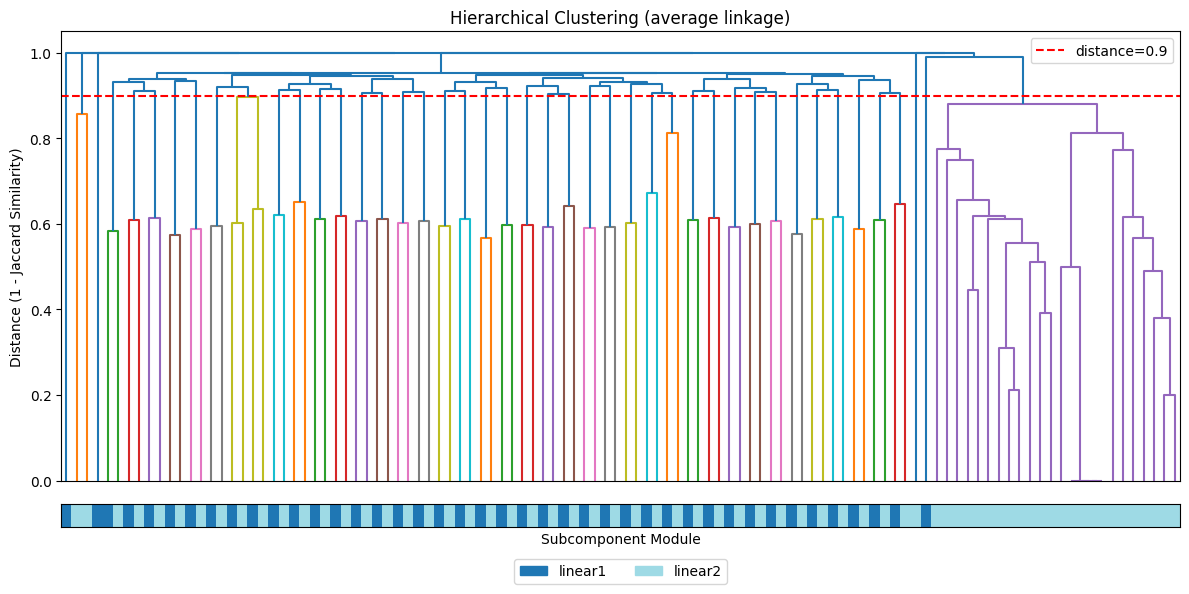

In [4]:
plot_clustering_from_results(
    results=coactivations_tms,
);

[ <ipykernel>:17 -> get_comp_dist_mat ] jac: μ=0.00 σ=0.03 x̃=0.00 R=[0.00,1.00] ℙ=|█      | shape=(400,400) dtype=torch.float32 device=cpu ∇✗
[ <ipykernel>:24 -> get_comp_dist_mat ] dist: μ=1.00 σ=0.02 x̃=1.00 R=[0.50,1.00] ℙ=|      █| shape=(400,400) dtype=torch.float32 device=cpu ∇✗


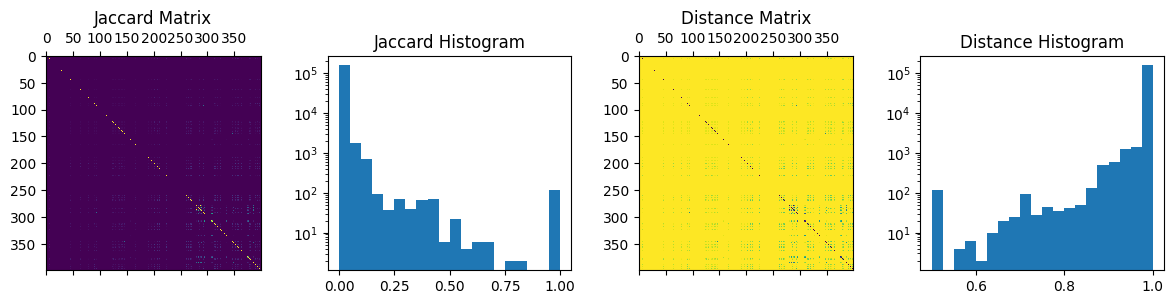

In [ ]:


tms_dist = get_comp_dist_mat(coactivations_tms["group_0"])

(9x) /home/miv/projects/MATS/apd/.venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132
(9x) /home/miv/projects/MATS/apd/.venv/lib/python3.11/site-packages/umap/umap_.py:1865


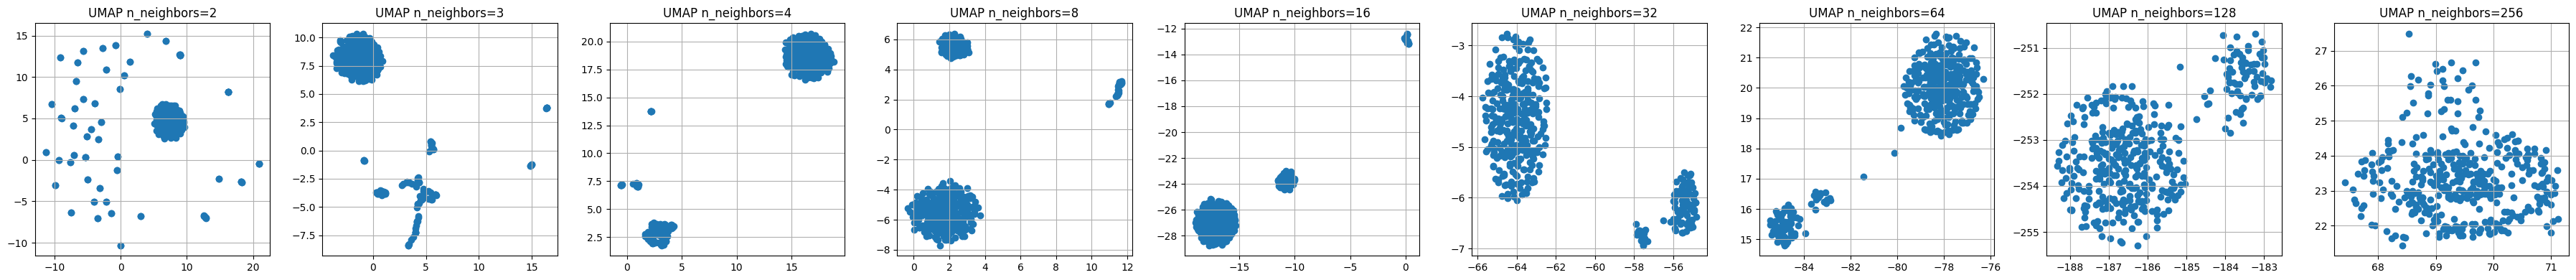

(1x) /home/miv/projects/MATS/apd/.venv/lib/python3.11/site-packages/sklearn/manifold/_isomap.py:384
(6x) /home/miv/projects/MATS/apd/.venv/lib/python3.11/site-packages/scipy/sparse/_index.py:168


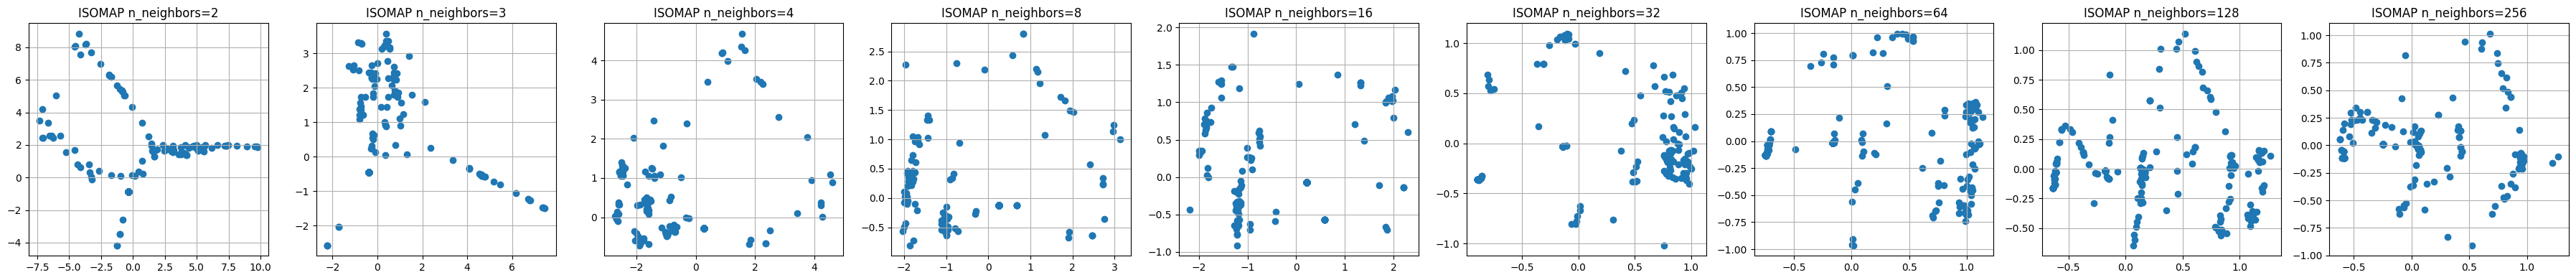

In [26]:
for method in ["umap", "isomap"]:
    plot_embedding_result(
        sweep_embedding_param(
            dist=tms_dist,
            method=method,
            param_name="n_neighbors",
            param_values=[2, 3, 4, 8, 16, 32, 64, 128, 256],
            n_components=2,
        )
    )

# 1 layer residual MLP

Number of alive elements: 150
Number of clusters: 101
Cluster sizes: [50  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1]


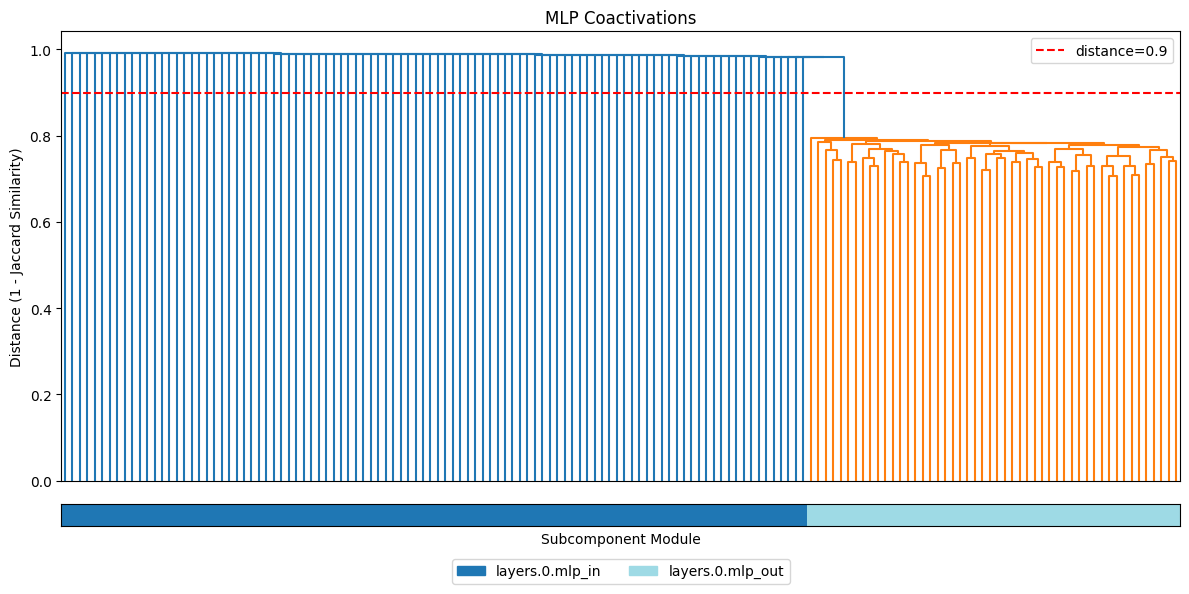

In [10]:
coactivations_mlp: CoactivationResults = get_coactivations(
    model_path=Path("../data/mlp-decomp/model_30000.pth"),
    dataset_cls=ResidualMLPDataset,
    dataset_kwargs=dict(
        calc_labels=False,  # Our labels will be the output of the target model
        label_type=None,
        act_fn_name=None,
        label_fn_seed=None,
        label_coeffs=None,
        synced_inputs=None,
    ),
    coactivations_kwargs=dict(
        module_groups=[["layers.0.mlp_in", "layers.0.mlp_out"]],
    ),
    device=DEVICE,
)
plot_clustering_from_results(
    results=coactivations_mlp,
    title="MLP Coactivations",
);

# 3 layer residual MLP

Number of alive elements: 405
Number of clusters: 113
Cluster sizes: [ 4  4  4  4  4  4  4  4  4  4  4  3  1  4  4  3  4  4  4  4  3  4  3  3
  4  3  2  4  4  3  4  3  3  3  4  3  2  4  3  3  1  4  3  1  3  1  3  2
  3  4  4  2  3  3  5  4  3  3  1  3  4  3  3  5  3  3  3  3  4  2  1  3
  3  3  4  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3
  3  3  3  3  3  3  3  3  3  3  3  3  3  3 51  3  3]


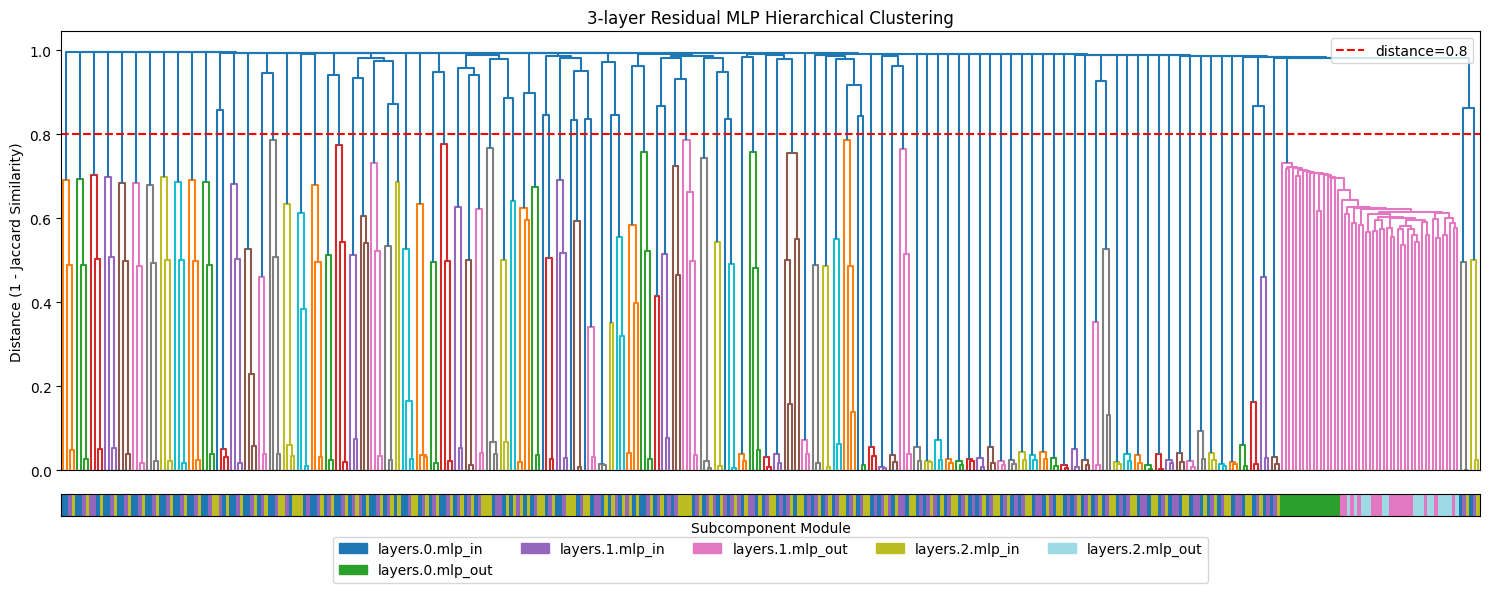

In [11]:
coactivations_mlp3: CoactivationResults = get_coactivations(
    model_path=Path("../data/mlp3-decomp/model_120000.pth"),
    dataset_cls=ResidualMLPDataset,
    dataset_kwargs=dict(
        calc_labels=False,  # Our labels will be the output of the target model
        label_type=None,
        act_fn_name=None,
        label_fn_seed=None,
        label_coeffs=None,
        synced_inputs=None,
    ),
    coactivations_kwargs=dict(
        module_groups=[
            [
                "layers.0.mlp_in",
                "layers.0.mlp_out",
                "layers.1.mlp_in",
                "layers.1.mlp_out",
                "layers.2.mlp_in",
                "layers.2.mlp_out",
            ]
        ],
    ),
    device=DEVICE,
)

_, mlp3_clusters, _, mlp3_alive_mask = plot_clustering_from_results(
    coactivations_mlp3,
    group_key="group_0",
    linkage_method="average",
    threshold=0.8,
    # linkage_method="complete",
    # threshold=0.85,
    title="3-layer Residual MLP Hierarchical Clustering",
    min_alive_counts=500,
    figsize=(15, 6),
)

In [12]:
submodules = coactivations_mlp3["group_0"]["labels"][mlp3_alive_mask]
# Get top 10 clusters by size
cluster_sizes = pd.Series(mlp3_clusters).value_counts()

for cluster_id in cluster_sizes.index[0::10]:
    cluster_mask = mlp3_clusters == cluster_id
    submodule_counts = pd.Series(submodules[cluster_mask]).value_counts()

    print(f"\nCluster {cluster_id} ({cluster_sizes[cluster_id]} elements):")
    for submodule, count in submodule_counts.items():
        print(f"  {submodule}: {count}")


Cluster 111 (51 elements):
  layers.0.mlp_out: 17
  layers.1.mlp_out: 17
  layers.2.mlp_out: 17

Cluster 31 (4 elements):
  layers.0.mlp_in: 2
  layers.1.mlp_in: 1
  layers.2.mlp_in: 1

Cluster 14 (4 elements):
  layers.0.mlp_in: 2
  layers.1.mlp_in: 1
  layers.2.mlp_in: 1

Cluster 8 (4 elements):
  layers.0.mlp_in: 2
  layers.1.mlp_in: 1
  layers.2.mlp_in: 1

Cluster 54 (3 elements):
  layers.0.mlp_in: 1
  layers.1.mlp_in: 1
  layers.2.mlp_in: 1

Cluster 73 (3 elements):
  layers.0.mlp_in: 1
  layers.1.mlp_in: 1
  layers.2.mlp_in: 1

Cluster 43 (3 elements):
  layers.0.mlp_in: 1
  layers.1.mlp_in: 1
  layers.2.mlp_in: 1

Cluster 103 (3 elements):
  layers.0.mlp_in: 1
  layers.1.mlp_in: 1
  layers.2.mlp_in: 1

Cluster 101 (3 elements):
  layers.0.mlp_in: 1
  layers.1.mlp_in: 1
  layers.2.mlp_in: 1

Cluster 78 (3 elements):
  layers.0.mlp_in: 1
  layers.1.mlp_in: 1
  layers.2.mlp_in: 1

Cluster 58 (3 elements):
  layers.0.mlp_in: 1
  layers.1.mlp_in: 1
  layers.2.mlp_in: 1

Cluster 41 